# Score Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

In [40]:
# df_assess = pd.read_csv("cleaned/final_assessment.csv")
# df_grades = pd.read_csv("cleaned/grades.csv")
# df_status = pd.read_csv("cleaned/status.csv")


df_assess = pd.read_csv("data/cleaned/final_assessment.csv")
df_grades = pd.read_csv("data/cleaned/grades.csv")
df_status = pd.read_csv("data/cleaned/status.csv")

In [41]:
display(df_assess.head())
display(df_grades.head())
display(df_status.head())

,id,1.1_score,1.1_confident_level,1.2_score,1.2_confident_level,1.3_score,1.3_confident_level,1.4_score,1.4_confident_level,2.1_score,2.1_confident_level,2.2_score,2.2_confident_level,2.3_score,2.3_confident_level,2.4_score,2.4_confident_level,3.1_score,3.1_confident_level,3.2_score,3.2_confident_level,3.3_score,3.3_confident_level,3.4_score,3.4_confident_level,3.5_score,3.5_confident_level,4.1_score,4.1_confident_level,5.1_score,5.1_confident_level,5.2_score,5.2_confident_level,5.3_score,5.3_confident_level,5.4_score,5.4_confident_level
0,0,0.75,4.0,1.0,4.0,1.0,4.0,1.0,2.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,0.0,0.0,4.0,1.0,4.0,0.0,0.0,0.6,4.0,1.0,3.0
1,1,0.75,5.0,0.8,4.0,0.0,2.0,1.0,3.0,0.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,3.0,0.0,4.0,1.0,5.0,1.0,3.0,1.0,3.0,1.0,4.0
2,3,1.00,4.0,1.0,3.0,1.0,4.0,1.0,4.0,1.0,NaN,1.0,2.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,0.0,3.0,1.0,4.0,1.0,4.0,1.0,3.0,0.0,3.0
3,6,1.00,2.0,1.0,3.0,1.0,1.0,1.0,4.0,0.0,0.0,1.0,2.0,1.0,4.0,0.0,2.0,0.0,3.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,1.0,0.0,1.0
4,9,0.50,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,4.0,1.0,4.0,0.0,NaN,0.0,NaN,1.0,2.0,1.0,5.0,0.0,NaN,0.8,2.0,0.0,1.0


,id,coding_score,handwritten_score,final_score,final_score_adj
0,0,NaN,NaN,0.737705,0.586066
1,1,0.928571,NaN,0.754098,0.610656
2,3,0.857143,1.0,0.836066,0.479508
3,6,NaN,1.0,0.459016,0.200820
4,9,0.904764,NaN,0.672131,0.471311


,id,section,completed
0,0,1,True
1,1,2,True
2,2,3,False
3,3,4,True
4,4,1,False


In [42]:
df_status = df_status[df_status["completed"] == 1].copy()

print("Completed students:", df_status.shape[0])
display(df_status["section"].value_counts())

Completed students: 17


section
1    5
2    4
4    4
3    4
Name: count, dtype: int64

In [43]:
df_id = (
    df_grades
    .merge(df_status[["id", "section"]], on="id", how="inner")
)

print("ID-level shape:", df_id.shape)
display(df_id.head())

ID-level shape: (17, 6)


,id,coding_score,handwritten_score,final_score,final_score_adj,section
0,0,NaN,NaN,0.737705,0.586066,1
1,1,0.928571,NaN,0.754098,0.610656,2
2,3,0.857143,1.0,0.836066,0.479508,4
3,6,NaN,1.0,0.459016,0.200820,3
4,9,0.904764,NaN,0.672131,0.471311,2


In [44]:
df_item = (
    df_assess
    .merge(df_status[["id", "section"]], on="id", how="inner")
)

print("Item-level shape:", df_item.shape)
display(df_item.head())

Item-level shape: (17, 38)


,id,1.1_score,1.1_confident_level,1.2_score,1.2_confident_level,1.3_score,1.3_confident_level,1.4_score,1.4_confident_level,2.1_score,2.1_confident_level,2.2_score,2.2_confident_level,2.3_score,2.3_confident_level,2.4_score,2.4_confident_level,3.1_score,3.1_confident_level,3.2_score,3.2_confident_level,3.3_score,3.3_confident_level,3.4_score,3.4_confident_level,3.5_score,3.5_confident_level,4.1_score,4.1_confident_level,5.1_score,5.1_confident_level,5.2_score,5.2_confident_level,5.3_score,5.3_confident_level,5.4_score,5.4_confident_level,section
0,0,0.75,4.0,1.0,4.0,1.0,4.0,1.0,2.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,0.0,0.0,4.0,1.0,4.0,0.0,0.0,0.6,4.0,1.0,3.0,1
1,1,0.75,5.0,0.8,4.0,0.0,2.0,1.0,3.0,0.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,0.0,3.0,0.0,4.0,1.0,5.0,1.0,3.0,1.0,3.0,1.0,4.0,2
2,3,1.00,4.0,1.0,3.0,1.0,4.0,1.0,4.0,1.0,NaN,1.0,2.0,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,0.0,3.0,1.0,4.0,1.0,4.0,1.0,3.0,0.0,3.0,4
3,6,1.00,2.0,1.0,3.0,1.0,1.0,1.0,4.0,0.0,0.0,1.0,2.0,1.0,4.0,0.0,2.0,0.0,3.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,1.0,0.0,1.0,3
4,9,0.50,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,4.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,5.0,1.0,4.0,1.0,4.0,0.0,NaN,0.0,NaN,1.0,2.0,1.0,5.0,0.0,NaN,0.8,2.0,0.0,1.0,2


In [45]:
df_id["group"] = df_id["section"]
df_item["group"] = df_item["section"]

### 1. Final assessment scores by group（boxplot）

C:\Users\atall\AppData\Local\Temp\ipykernel_25112\398131605.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups, showfliers=False)


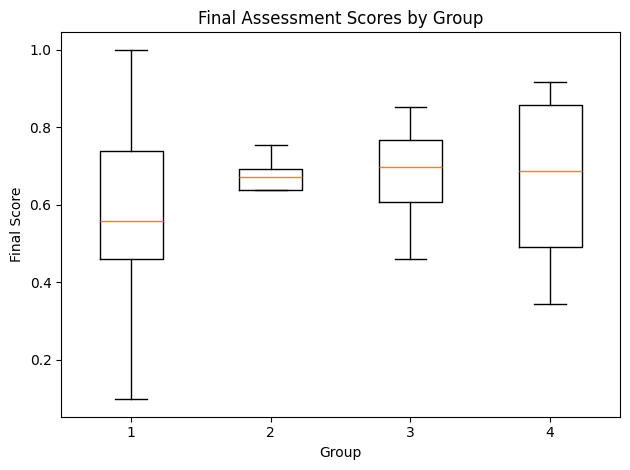

In [46]:
groups = sorted(df_id["group"].unique())
data = [df_id.loc[df_id["group"] == g, "final_score"] for g in groups]

plt.figure()
plt.boxplot(data, labels=groups, showfliers=False)
plt.xlabel("Group")
plt.ylabel("Final Score")
plt.title("Final Assessment Scores by Group")
plt.tight_layout()
plt.show()

### 2. Final assessment scores adjusted for confidence（boxplot）

C:\Users\atall\AppData\Local\Temp\ipykernel_25112\3316147613.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_adj, labels=groups, showfliers=False)


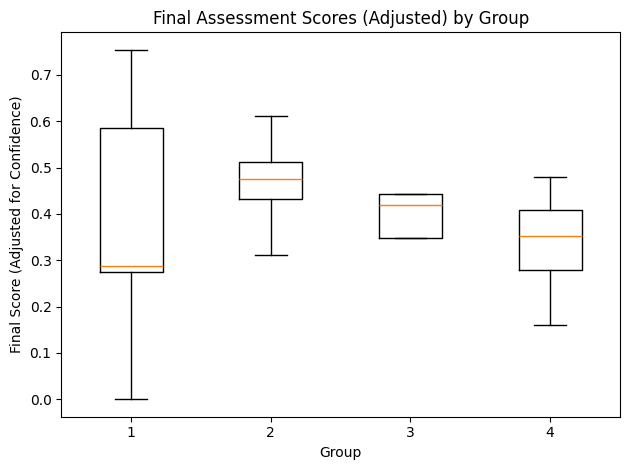

In [47]:
data_adj = [df_id.loc[df_id["group"] == g, "final_score_adj"] for g in groups]

plt.figure()
plt.boxplot(data_adj, labels=groups, showfliers=False)
plt.xlabel("Group")
plt.ylabel("Final Score (Adjusted for Confidence)")
plt.title("Final Assessment Scores (Adjusted) by Group")
plt.tight_layout()
plt.show()

### 3. Standard Deviations/Means by subquestion（rescaled 0–1）

In [48]:
score_cols = [c for c in df_item.columns if c.endswith("_score")]

print("Number of subquestions:", len(score_cols))
print(score_cols)

Number of subquestions: 18
['1.1_score', '1.2_score', '1.3_score', '1.4_score', '2.1_score', '2.2_score', '2.3_score', '2.4_score', '3.1_score', '3.2_score', '3.3_score', '3.4_score', '3.5_score', '4.1_score', '5.1_score', '5.2_score', '5.3_score', '5.4_score']


In [49]:
long_scores = (
    df_item[["id"] + score_cols]
    .melt(
        id_vars="id",
        value_vars=score_cols,
        var_name="subquestion",
        value_name="score"
    )
)

# clean subquestion name: '1.1_score' -> '1.1'
long_scores["subquestion"] = long_scores["subquestion"].str.replace("_score", "", regex=False)

print("Long score table shape:", long_scores.shape)
display(long_scores.head())

Long score table shape: (306, 3)


,id,subquestion,score
0,0,1.1,0.75
1,1,1.1,0.75
2,3,1.1,1.00
3,6,1.1,1.00
4,9,1.1,0.50


In [50]:
std_by_subq = (
    long_scores
    .groupby("subquestion")
    .agg(std_score=("score", "std"))
    .reset_index()
    .sort_values("std_score", ascending=False)
)

In [51]:
mean_by_subq = (
    long_scores
    .groupby("subquestion")
    .agg(mean_score=("score", "mean"))
    .reset_index()
    .sort_values("mean_score")
)

In [52]:
subquestion_summary = (
    long_scores
    .groupby("subquestion")
    .agg(
        mean_score=("score", "mean"),
        std_score=("score", "std"),
        n=("score", "count")
    )
    .reset_index()
    .sort_values("subquestion")
)

display(subquestion_summary)

,subquestion,mean_score,std_score,n
0,1.1,0.779412,0.263426,17
1,1.2,0.870588,0.264019,17
2,1.3,0.705882,0.469668,17
3,1.4,0.808824,0.325113,17
4,2.1,0.705882,0.469668,17
5,2.2,0.823529,0.392953,17
6,2.3,1.000000,0.000000,17
7,2.4,0.764706,0.437237,17
8,3.1,0.823529,0.392953,17
9,3.2,0.705882,0.469668,17


### 4. Boxplots by section for any subquestions of interest

In [53]:
# helper function to add rank labels
def add_rank_label(df, label_prefix, score_col, ascending):
    df = df.sort_values(score_col, ascending=ascending).head(2).copy()
    df["selection_reason"] = [
        f"1st {label_prefix}",
        f"2nd {label_prefix}"
    ]
    return df


# 1) highest mean
highest_mean_2 = add_rank_label(
    subquestion_summary,
    label_prefix="highest mean",
    score_col="mean_score",
    ascending=False
)

# 2) lowest mean
lowest_mean_2 = add_rank_label(
    subquestion_summary,
    label_prefix="lowest mean",
    score_col="mean_score",
    ascending=True
)

# 3) highest std
highest_std_2 = add_rank_label(
    subquestion_summary,
    label_prefix="highest std",
    score_col="std_score",
    ascending=False
)

# 4) lowest std
lowest_std_2 = add_rank_label(
    subquestion_summary,
    label_prefix="lowest std",
    score_col="std_score",
    ascending=True
)

# combine all
interest_subqs = pd.concat([
    highest_mean_2,
    lowest_mean_2,
    highest_std_2,
    lowest_std_2
])

# merge labels if a subquestion appears multiple times
interest_subqs = (
    interest_subqs
    .groupby(["subquestion", "mean_score", "std_score", "n"], as_index=False)
    .agg({
        "selection_reason": lambda x: "; ".join(sorted(set(x)))
    })
    .sort_values("subquestion")
)

display(interest_subqs)

,subquestion,mean_score,std_score,n,selection_reason
0,1.1,0.779412,0.263426,17,2nd lowest std
1,1.2,0.870588,0.264019,17,2nd highest mean
2,2.3,1.000000,0.000000,17,1st highest mean; 1st lowest std
3,3.4,0.529412,0.514496,17,1st highest std
4,3.5,0.294118,0.469668,17,2nd lowest mean
5,4.1,0.529412,0.514496,17,2nd highest std
6,5.4,0.235294,0.437237,17,1st lowest mean


In [54]:
# Sanity check: 3.4 and 4.1 are different subquestions by design.
# We test whether their raw score vectors differ in the dataset; if this returns True,
# the two items happen to have identical observed scores in the current sample.
s34 = long_scores[long_scores["subquestion"] == "3.4"]["score"].reset_index(drop=True)
s41 = long_scores[long_scores["subquestion"] == "4.1"]["score"].reset_index(drop=True)

(s34 == s41).all()

False

In [55]:
# merge section info
long_scores_sec = long_scores.merge(
    df_item[["id", "section"]].drop_duplicates(),
    on="id",
    how="left"
)

C:\Users\atall\AppData\Local\Temp\ipykernel_25112\1879914859.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


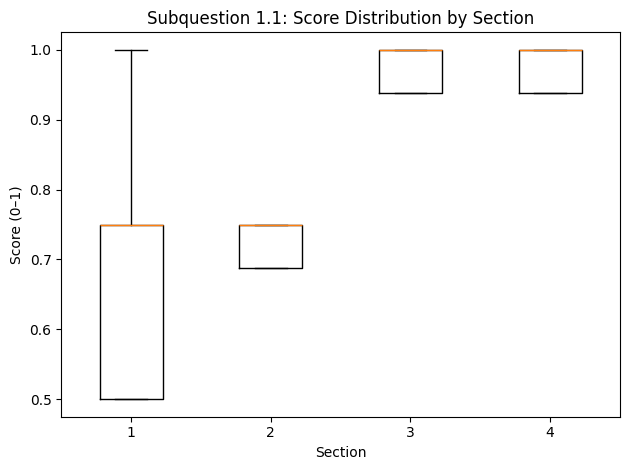

C:\Users\atall\AppData\Local\Temp\ipykernel_25112\1879914859.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


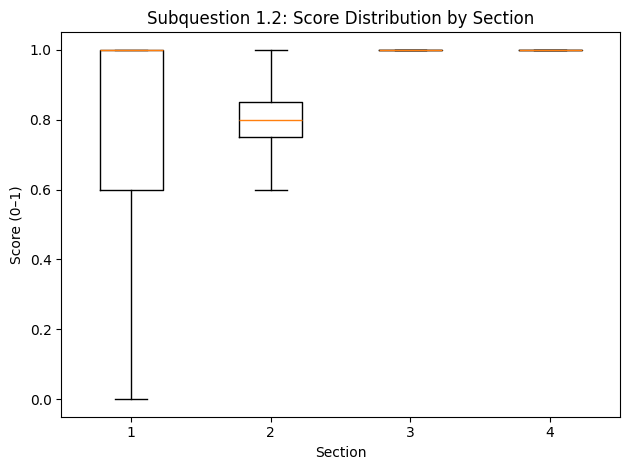

C:\Users\atall\AppData\Local\Temp\ipykernel_25112\1879914859.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


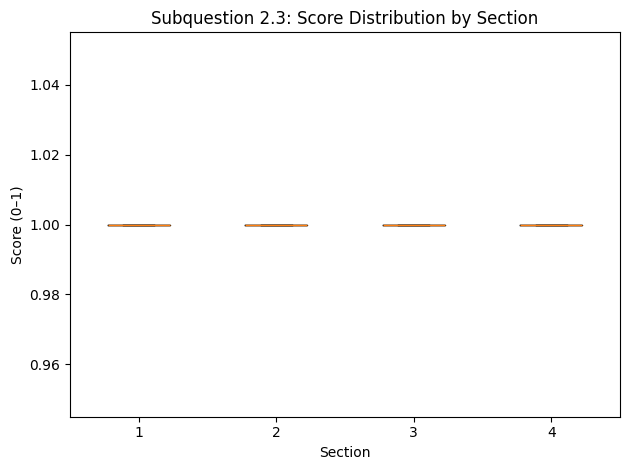

C:\Users\atall\AppData\Local\Temp\ipykernel_25112\1879914859.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


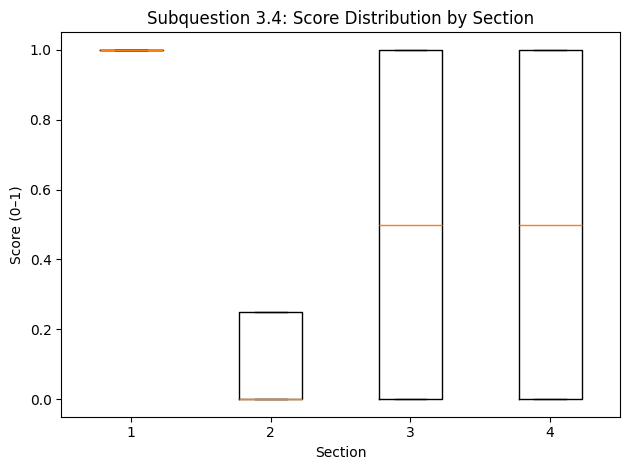

C:\Users\atall\AppData\Local\Temp\ipykernel_25112\1879914859.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


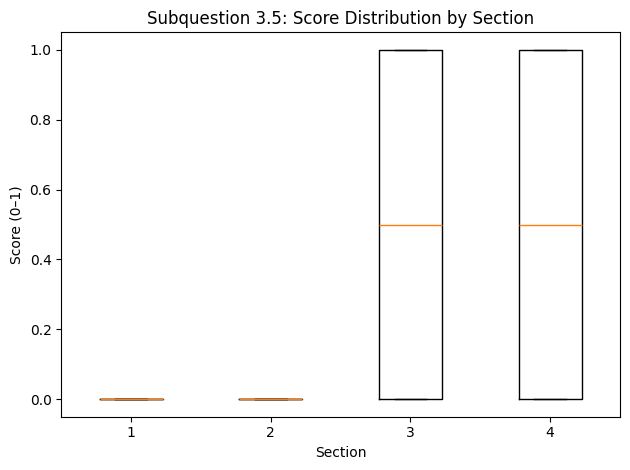

C:\Users\atall\AppData\Local\Temp\ipykernel_25112\1879914859.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


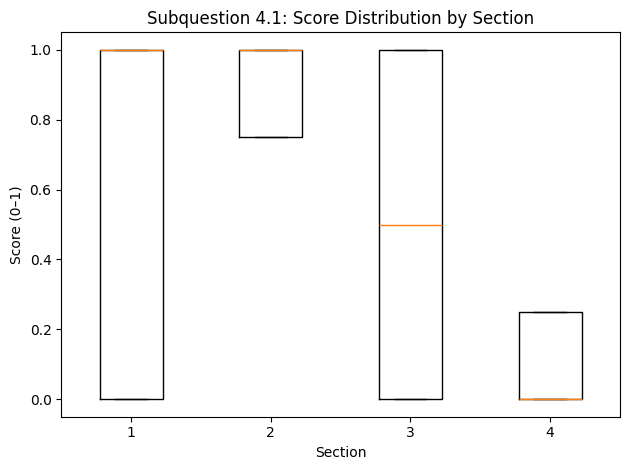

C:\Users\atall\AppData\Local\Temp\ipykernel_25112\1879914859.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


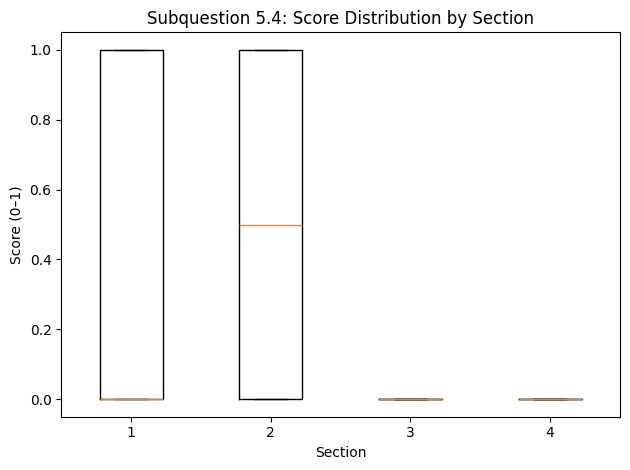

In [56]:
import matplotlib.pyplot as plt

sections = sorted(long_scores_sec["section"].unique())

for sq in interest_subqs["subquestion"]:
    data = [
        long_scores_sec.loc[
            (long_scores_sec["subquestion"] == sq) &
            (long_scores_sec["section"] == sec),
            "score"
        ]
        for sec in sections
    ]
    
    plt.figure()
    plt.boxplot(data, labels=sections, showfliers=False)
    plt.xlabel("Section")
    plt.ylabel("Score (0–1)")
    plt.title(f"Subquestion {sq}: Score Distribution by Section")
    plt.tight_layout()
    plt.show()

### Completeness by group

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# df_status = pd.read_csv("../cleaned/status.csv")
df_status = pd.read_csv("data/cleaned/status.csv")

print(df_status.shape)
display(df_status.head())

(40, 3)


,id,section,completed
0,0,1,True
1,1,2,True
2,2,3,False
3,3,4,True
4,4,1,False


In [58]:
df_status["completed"] = (
    df_status["completed"]
    .astype(str)
    .str.upper()
    .map({"TRUE": True, "FALSE": False})
)

print("Completed value counts:")
display(df_status["completed"].value_counts(dropna=False))

Completed value counts:


completed
False    23
True     17
Name: count, dtype: int64

In [59]:
completeness_by_section = (
    df_status
    .groupby("section")
    .agg(
        n_total=("completed", "size"),
        n_completed=("completed", "sum"),      # True = 1
        completion_rate=("completed", "mean")  # proportion TRUE
    )
    .reset_index()
)

display(completeness_by_section)

,section,n_total,n_completed,completion_rate
0,1,10,5,0.5
1,2,10,4,0.4
2,3,10,4,0.4
3,4,10,4,0.4


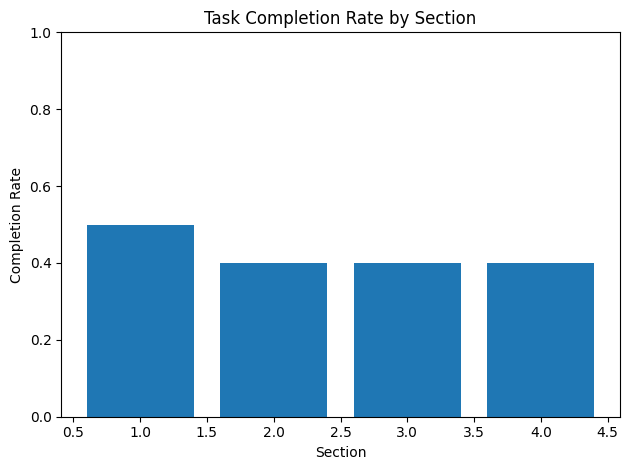

In [60]:
plt.figure()
plt.bar(
    completeness_by_section["section"],
    completeness_by_section["completion_rate"]
)
plt.xlabel("Section")
plt.ylabel("Completion Rate")
plt.ylim(0, 1)
plt.title("Task Completion Rate by Section")
plt.tight_layout()
plt.show()

# Confidence Level Analysis

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# df_assess = pd.read_csv("cleaned/final_assessment.csv")
# df_status = pd.read_csv("cleaned/status.csv")

df_assess = pd.read_csv("data/cleaned/final_assessment.csv")
df_status = pd.read_csv("data/cleaned/status.csv")

# keep only completed students
df_status = df_status[df_status["completed"] == 1].copy()

# merge assessment + section
df_item = df_assess.merge(df_status[["id", "section"]], on="id", how="inner")
print("df_item shape:", df_item.shape)

df_item shape: (17, 38)


In [63]:
# identify columns
score_cols = [c for c in df_item.columns if c.endswith("_score")]
conf_cols  = [c for c in df_item.columns if c.endswith("_confident_level")]

print("Num score cols:", len(score_cols))
print("Num conf cols:", len(conf_cols))

# reshape scores long
long_scores = (
    df_item[["id", "section"] + score_cols]
    .melt(id_vars=["id", "section"], value_vars=score_cols,
          var_name="subquestion", value_name="score")
)
long_scores["subquestion"] = long_scores["subquestion"].str.replace("_score", "", regex=False)

# reshape confidence long
long_conf = (
    df_item[["id", "section"] + conf_cols]
    .melt(id_vars=["id", "section"], value_vars=conf_cols,
          var_name="subquestion", value_name="confidence")
)
long_conf["subquestion"] = long_conf["subquestion"].str.replace("_confident_level", "", regex=False)

# merge into one tidy table: one row per (id, section, subquestion)
long_sc = long_scores.merge(long_conf, on=["id", "section", "subquestion"], how="inner")

# type cleaning
long_sc["score"] = pd.to_numeric(long_sc["score"], errors="coerce")
long_sc["confidence"] = pd.to_numeric(long_sc["confidence"], errors="coerce")

print("long_sc shape:", long_sc.shape)
display(long_sc.head())

Num score cols: 18
Num conf cols: 18
long_sc shape: (306, 5)


,id,section,subquestion,score,confidence
0,0,1,1.1,0.75,4.0
1,1,2,1.1,0.75,5.0
2,3,4,1.1,1.00,4.0
3,6,3,1.1,1.00,2.0
4,9,2,1.1,0.50,4.0


In [64]:
conf_fill_by_section = (
    long_sc
    .groupby("section", dropna=False)
    .agg(
        n_rows=("confidence", "size"),
        conf_non_missing=("confidence", lambda s: s.notna().sum()),
        conf_fill_rate=("confidence", lambda s: s.notna().mean())
    )
    .reset_index()
)

display(conf_fill_by_section)

,section,n_rows,conf_non_missing,conf_fill_rate
0,1,90,80,0.888889
1,2,72,69,0.958333
2,3,72,72,1.000000
3,4,72,64,0.888889


C:\Users\atall\AppData\Local\Temp\ipykernel_25112\1296897967.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sections, showfliers=False)


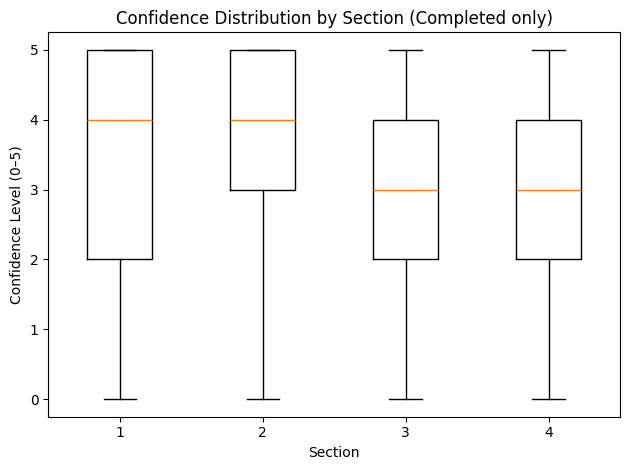

In [65]:
conf_nonmiss = long_sc.dropna(subset=["confidence"]).copy()
sections = sorted(conf_nonmiss["section"].unique())

data = [conf_nonmiss.loc[conf_nonmiss["section"] == sec, "confidence"] for sec in sections]

plt.figure()
plt.boxplot(data, labels=sections, showfliers=False)
plt.xlabel("Section")
plt.ylabel("Confidence Level (0–5)")
plt.title("Confidence Distribution by Section (Completed only)")
plt.tight_layout()
plt.show()

,confidence,n,mean_score,std_score
0,0.0,30,0.150000,0.351107
1,1.0,18,0.391667,0.481496
2,2.0,42,0.650000,0.472280
3,3.0,53,0.655660,0.452308
4,4.0,85,0.867059,0.313159
5,5.0,57,0.896491,0.288911


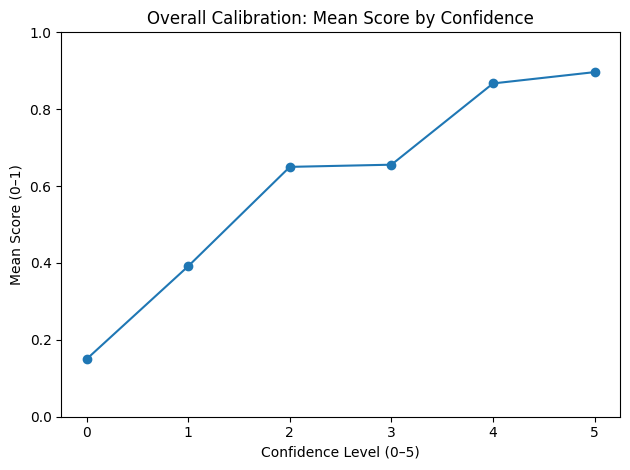

In [66]:
calib_overall = (
    long_sc
    .dropna(subset=["confidence", "score"])
    .groupby("confidence", dropna=False)
    .agg(
        n=("score", "size"),
        mean_score=("score", "mean"),
        std_score=("score", "std")
    )
    .reset_index()
    .sort_values("confidence")
)

display(calib_overall)

plt.figure()
plt.plot(calib_overall["confidence"], calib_overall["mean_score"], marker="o")
plt.xlabel("Confidence Level (0–5)")
plt.ylabel("Mean Score (0–1)")
plt.title("Overall Calibration: Mean Score by Confidence")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

,section,confidence,n,mean_score
0,1,0.0,13,0.192308
1,1,1.0,4,0.500000
2,1,2.0,5,0.400000
3,1,3.0,12,0.654167
4,1,4.0,25,0.814000
5,1,5.0,21,0.952381
6,2,0.0,2,0.000000
7,2,1.0,5,0.410000
8,2,2.0,6,0.633333
9,2,3.0,8,0.600000


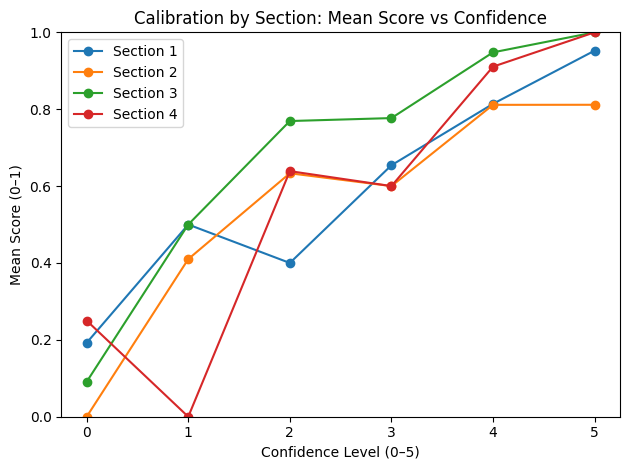

In [67]:
calib_by_section = (
    long_sc
    .dropna(subset=["confidence", "score"])
    .groupby(["section", "confidence"], dropna=False)
    .agg(n=("score", "size"), mean_score=("score", "mean"))
    .reset_index()
    .sort_values(["section", "confidence"])
)

display(calib_by_section.head(20))

plt.figure()
for sec in sorted(calib_by_section["section"].unique()):
    tmp = calib_by_section[calib_by_section["section"] == sec]
    plt.plot(tmp["confidence"], tmp["mean_score"], marker="o", label=f"Section {sec}")
plt.xlabel("Confidence Level (0–5)")
plt.ylabel("Mean Score (0–1)")
plt.title("Calibration by Section: Mean Score vs Confidence")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
calib_by_subq = (
    long_sc
    .dropna(subset=["confidence", "score"])
    .groupby(["subquestion", "confidence"], dropna=False)
    .agg(
        n=("score", "size"),
        mean_score=("score", "mean"),
        std_score=("score", "std")
    )
    .reset_index()
    .sort_values(["subquestion", "confidence"])
)

display(calib_by_subq.head(30))

# (Optional) pivot to make it easy to compare across confidence levels
calib_pivot = calib_by_subq.pivot(index="subquestion", columns="confidence", values="mean_score")
display(calib_pivot)

,subquestion,confidence,n,mean_score,std_score
0,1.1,2.0,1,1.000000,NaN
1,1.1,3.0,5,0.650000,0.418330
2,1.1,4.0,9,0.833333,0.176777
3,1.1,5.0,2,0.750000,0.000000
4,1.2,2.0,3,0.666667,0.577350
5,1.2,3.0,7,0.942857,0.151186
6,1.2,4.0,6,0.933333,0.103280
7,1.2,5.0,1,0.600000,NaN
8,1.3,0.0,1,1.000000,NaN
9,1.3,1.0,2,0.500000,0.707107


confidence,0.0,1.0,2.0,3.0,4.0,5.0
subquestion,,,,,,
1.1,NaN,NaN,1.000000,0.650000,0.833333,0.750000
1.2,NaN,NaN,0.666667,0.942857,0.933333,0.600000
1.3,1.000000,0.500000,0.500000,0.500000,1.000000,1.000000
1.4,0.500000,0.250000,0.900000,0.875000,0.833333,NaN
2.1,0.000000,NaN,0.000000,0.666667,0.857143,0.750000
2.2,1.000000,NaN,0.666667,0.000000,1.000000,1.000000
2.3,1.000000,NaN,1.000000,1.000000,1.000000,1.000000
2.4,NaN,NaN,0.000000,1.000000,0.750000,1.000000
3.1,NaN,0.000000,NaN,0.500000,1.000000,1.000000


In [69]:
# overall correlation
tmp = long_sc.dropna(subset=["confidence", "score"])
overall_corr = tmp["confidence"].corr(tmp["score"])
print("Overall Pearson corr(confidence, score):", overall_corr)

# correlation by section
corr_by_section = (
    tmp.groupby("section")
       .apply(lambda g: g["confidence"].corr(g["score"]))
       .reset_index(name="corr_conf_score")
)
display(corr_by_section)

Overall Pearson corr(confidence, score): 0.5054592743195204


C:\Users\atall\AppData\Local\Temp\ipykernel_25112\1270350930.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp.groupby("section")


,section,corr_conf_score
0,1,0.586473
1,2,0.374276
2,3,0.636211
3,4,0.438398
